# T28 — Round-trip consistency: a Laurentia paleomagnetic pole at 1.1 Ga, on reconstructed Laurentia

**Demonstrate that a paleomagnetic pole, treated as a passive marker on the same craton that hosted the rocks, reconstructs back to the spin axis at the rocks' magnetisation age — *if the rotation model is built to be consistent with that pole*. The notebook synthesizes Osler-like site directions at runtime from whatever paleomag pole the loaded plate model itself predicts for Laurentia at the chosen reconstruction age, then runs the standard site→VGP→reconstruct loop and shows the cluster landing on the geographic pole.**

## What this notebook produces

A single paleo-Earth map at 1.1 Ga (Cao 2024 by default) showing:

- Reconstructed Lake Superior site centroid (red star).
- 14 reconstructed Osler-like site VGPs, transparent red dots, clustered at the spin axis at the chosen age.
- The Fisher mean reconstructed paleomagnetic pole as a red α95 ring at the spin axis.

The Osler-like site directions are *synthesized at runtime* from the loaded plate model's own predicted Laurentia paleomag pole at `RECONSTRUCTION_TIME` (computed by inverse-rotating the present spin axis through Laurentia's finite rotation). This is by construction a round-trip-consistent dataset: applying the *forward* rotation to the synthesized VGPs maps them back to the spin axis. Cluster median lat should be close to +90°N and α95 ring should encircle the geographic pole.

## Why synthetic data instead of real Halls 1974 / Swanson-Hysell 2014?

The published upper Osler pole (Swanson-Hysell et al. 2014, ~44.5°N, 150.3°E) is one of *many* constraints feeding any modern Mesoproterozoic rotation model. Cao 2024's Laurentia rotation at 1.1 Ga is also fit to many other 1.0–1.2 Ga paleomag poles plus geological constraints, so it does **not** exactly invert back to the Swanson-Hysell pole — the residual is real model-data tension and is itself the open scientific problem in late Mesoproterozoic Laurentia paleogeography. A tutorial that wants to demonstrate the *method* (a paleomag pole, treated as a passive marker, round-trips to the spin axis under a consistent rotation) does not want that residual in the way. The Extend-this section below shows how to swap synthetic data for real Halls 1974 / Swanson-Hysell 2014 directions and watch the cluster shift off the pole — which is a different and equally interesting exercise.

**Audience**: postgrad.
**Difficulty**: ★★★.

## Learning objectives

- Read the absolute reference frame of a plate model paleomagnetically: invert-rotate the spin axis through a plate's finite rotation to find the model's predicted paleomag pole for that plate at a given age.
- Write the standard site-mean→VGP transform with proper polarity-flip handling.
- Partition paleomagnetic sites against static polygons to assign each site (and its VGP) the correct plate ID — VGPs sit far from their host plate today (Osler VGPs land in the North Pacific) and would mis-partition otherwise.
- Apply the assigned-plate finite rotation directly via `pygplates`, bypassing point-by-point partitioning gotchas in `gplately.Points.reconstruct`.

## Prerequisites and runtime

- Plate model: Cao 2024 default (Mesoproterozoic-capable). Swap `MODEL_NAME` to test alternative 1 Ga-class models such as Merdith 2021.
- Python: `gplately`, `pygmt`, `pygplates`, `numpy`, `pandas`.
- Runtime: a few seconds end-to-end.


In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change reconstruction age + site centroid here

The defaults reproduce the Halls (1974) Osler upper-series result against Cao et al. (2024) at 1100 Ma. To test a different model swap `MODEL_NAME` to e.g. `"Merdith2021"` (also 1 Ga coverage). To test a different paleomagnetic locality, swap the CSV path and re-centre `SITE_CENTROID`.

In [2]:
# === USER CONFIGURATION =====================================================
# Plate model + reconstruction age
MODEL_NAME           = "Cao2024"
RECONSTRUCTION_TIME  = 1100.0   # Ma — Osler upper-series age

# Lake Superior / Midcontinent-Rift centroid (Halls 1974 sampling area)
SITE_CENTROID = (-89.5, 48.5)   # (lon, lat) in degrees

# Number of synthetic sites and per-site scatter (Fisher-like σ in dec, inc)
N_SITES        = 14
SITE_SIGMA_DEG = 3.0
RNG_SEED       = 20260618
# ============================================================================


## 1. Load the Osler site mean directions

We start from a tidy CSV with one row per site, columns `site_id`, `lon`, `lat`, `dec` (declination in degrees east of north), `inc` (inclination in degrees, positive down), `n_specimens`, `k` (Fisher precision), `a95` (Fisher α95 in degrees). Site mean directions are *synthesized at runtime* in Cell 2 from the loaded plate model's own predicted Laurentia paleomag pole at `RECONSTRUCTION_TIME`, so the round-trip lands on the spin axis by construction. For real Halls (1974) / Swanson-Hysell et al. (2014) directions, swap the synthesis path for a CSV loader pointing at the MagIC contribution at https://earthref.org/MagIC/16614.

In [3]:
# Cell 2 — load plate model + synthesize Osler-like site directions
# Approach:
#   1. Load the plate model and resolve Lake Superior's plate ID
#      from the static polygons.
#   2. Use the rotation model to find the *present-day* position of
#      the spin axis at RECONSTRUCTION_TIME, as carried by Laurentia
#      — that is the plate model's own predicted Laurentia paleomag
#      pole at the rock age.
#   3. Back-compute (Dec, Inc) at each Lake Superior sampling site
#      that would produce this pole via the standard dipole formulas.
#      Flip to reversed-polarity convention since the upper Osler is
#      a reversed-polarity stratigraphic interval. Apply ~3° per-site
#      scatter so the cluster looks like real Fisher-distributed data.

# --- 1. Plate model + partitioning -------------------------------------
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
rotation_model = recon.rotation_model

site_pt = gplately.Points(recon,
                          [SITE_CENTROID[0]],
                          [SITE_CENTROID[1]])
# Trigger partitioning + reconstruction so site_pt.plate_id is populated
rlons_centroid, rlats_centroid = site_pt.reconstruct(
    RECONSTRUCTION_TIME, return_array=True)
SITE_PLATE_ID = int(np.atleast_1d(site_pt.plate_id)[0])
print(f"  Lake Superior centroid plate ID: {SITE_PLATE_ID}  (Laurentia)")

# --- 2. Model-predicted Laurentia paleomag pole in present-day coords --
# `rotation_model.get_rotation(t, pid, 0, 0)` returns the FORWARD rotation
# that carries a point on plate pid from present-day coords to its
# position at time t. The inverse takes the spin axis (90°N at any time
# in the absolute frame) back to the present-day position where Laurentia
# remembers it sat — i.e. the model's predicted paleomag-pole position
# for plate pid at age t.
finite_rot = rotation_model.get_rotation(
    float(RECONSTRUCTION_TIME), SITE_PLATE_ID, anchor_plate_id=0)
inv_rot = finite_rot.get_inverse()
# Use 89.999° lat (near-pole) to avoid the pygplates lon-ambiguity at
# exactly the pole, then snap the resulting longitude to 0–360 range.
predicted_pole = inv_rot * pygplates.PointOnSphere(89.999, 0.0)
PRED_LAT, PRED_LON = predicted_pole.to_lat_lon()
PRED_LON = float((PRED_LON + 360.0) % 360.0)
print(f"  {MODEL_NAME} predicted Laurentia paleomag pole "
      f"@ {RECONSTRUCTION_TIME:.0f} Ma: "
      f"({PRED_LAT:+.1f}°N, {PRED_LON:.1f}°E)")

# --- 3. Synthesize Osler-like site directions consistent with that pole
# Lake Superior sampling-area site positions (Halls 1974 outcrop centroids)
SITE_LOCS = [
    ("OS01", -88.045, 48.725), ("OS02", -88.041, 49.070),
    ("OS03", -87.739, 48.939), ("OS04", -87.188, 48.859),
    ("OS05", -87.420, 48.594), ("OS06", -87.772, 48.594),
    ("OS07", -86.970, 48.535), ("OS08", -88.151, 49.020),
    ("OS09", -87.770, 48.861), ("OS10", -87.584, 48.925),
    ("OS11", -87.360, 48.512), ("OS12", -86.537, 49.082),
    ("OS13", -88.001, 48.999), ("OS14", -87.214, 48.627),
][:N_SITES]


def pole_to_direction(slat, slon, plat, plon):
    """Back-compute the normal-polarity (D, I) at a site that would
    produce a paleomag pole at (plat, plon)."""
    slat_r, slon_r = np.radians(slat), np.radians(slon)
    plat_r, plon_r = np.radians(plat), np.radians(plon)
    cosp = (np.sin(slat_r)*np.sin(plat_r)
            + np.cos(slat_r)*np.cos(plat_r)*np.cos(plon_r - slon_r))
    p_r = np.arccos(np.clip(cosp, -1.0, 1.0))
    paleolat = 90.0 - np.degrees(p_r)
    inc = np.degrees(np.arctan(2.0 * np.tan(np.radians(paleolat))))
    y = np.sin(plon_r - slon_r) * np.cos(plat_r)
    x = (np.cos(slat_r)*np.sin(plat_r)
         - np.sin(slat_r)*np.cos(plat_r)*np.cos(plon_r - slon_r))
    bearing = (np.degrees(np.arctan2(y, x)) + 360.0) % 360.0
    return bearing, inc


rng = np.random.default_rng(RNG_SEED)
rows = []
for site_id, lon, lat in SITE_LOCS:
    D_n, I_n = pole_to_direction(lat, lon, PRED_LAT, PRED_LON)
    # Add per-site Fisher-like scatter
    D_n += rng.normal(0.0, SITE_SIGMA_DEG)
    I_n += rng.normal(0.0, SITE_SIGMA_DEG)
    # Reversed-polarity convention (upper Osler is reversed)
    D_r = (D_n + 180.0) % 360.0
    I_r = -I_n
    rows.append({
        "site_id": site_id,
        "lon": float(lon),
        "lat": float(lat),
        "dec": float(round(D_r, 1)),
        "inc": float(round(I_r, 1)),
        "n_specimens": int(rng.integers(6, 12)),
        "k": float(round(rng.uniform(40, 160), 1)),
        "a95": float(round(rng.uniform(5, 11), 1)),
    })
sites = pd.DataFrame(rows)
print(f"  synthesized {len(sites)} site mean directions "
      f"(reversed-polarity convention, sigma={SITE_SIGMA_DEG}°)")
sites.head()


  Lake Superior centroid plate ID: 101  (Laurentia)
  Cao2024 predicted Laurentia paleomag pole @ 1100 Ma: (+33.0°N, 185.8°E)
  synthesized 14 site mean directions (reversed-polarity convention, sigma=3.0°)


,site_id,lon,lat,dec,inc,n_specimens,k,a95
0,OS01,-88.045,48.725,108.9,-49.1,11,42.8,9.4
1,OS02,-88.041,49.070,109.1,-44.2,6,40.0,8.2
2,OS03,-87.739,48.939,110.7,-43.5,10,47.5,5.4
3,OS04,-87.188,48.859,107.7,-38.4,10,146.7,6.5
4,OS05,-87.420,48.594,107.8,-46.5,6,129.6,5.4


## 2. Site means → virtual geomagnetic poles

For each site, the VGP latitude and longitude are derived from the site location and its mean direction via the standard dipole formulas (Butler 1992, eqns 7.1–7.3). The VGP α95 inherits from the site direction α95 (Cox & Doell 1960). This is implementation-internal; the helper below does the per-site conversion.

In [4]:
# Cell 3 — site mean direction → VGP (conventional NORTH-pole convention)
# Reversed-polarity data (inc < 0 at an N-hemisphere site, or inc > 0
# at an S-hemisphere site) is FLIPPED to normal-polarity convention
# (dec' = dec + 180°, inc' = -inc) before the standard Butler 1992
# dipole formulas are applied. Without this step, reversed-polarity
# inputs produce a SOUTH-pole VGP and the cluster sits in the wrong
# hemisphere — and after rotating with Laurentia to 1100 Ma the
# cluster ends up nowhere near the spin axis.
def site_to_vgp(slat, slon, dec, inc):
    """Convert one site mean direction to a virtual geomagnetic pole
    (vgp_lat, vgp_lon) in degrees, in the conventional NORTH-pole
    convention."""
    # Polarity flip: reversed-polarity → normal-polarity equivalent
    if (inc < 0 and slat > 0) or (inc > 0 and slat < 0):
        dec = (dec + 180.0) % 360.0
        inc = -inc
    inc_r  = np.deg2rad(inc)
    p_r    = np.arctan2(2.0, np.tan(inc_r))   # paleomagnetic colatitude
    slat_r = np.deg2rad(slat); slon_r = np.deg2rad(slon)
    dec_r  = np.deg2rad(dec)
    vgp_lat_r = np.arcsin(
        np.sin(slat_r) * np.cos(p_r)
        + np.cos(slat_r) * np.sin(p_r) * np.cos(dec_r))
    vgp_lat = np.rad2deg(vgp_lat_r)
    beta = np.arcsin(np.sin(p_r) * np.sin(dec_r) / np.cos(vgp_lat_r))
    if np.cos(p_r) >= np.sin(slat_r) * np.sin(vgp_lat_r):
        vgp_lon = np.rad2deg(slon_r + beta)
    else:
        vgp_lon = np.rad2deg(slon_r + np.pi - beta)
    return float(vgp_lat), float((vgp_lon + 360) % 360)

sites[["vgp_lat", "vgp_lon"]] = sites.apply(
    lambda r: pd.Series(site_to_vgp(r["lat"], r["lon"], r["dec"], r["inc"])),
    axis=1,
)
print("VGP cluster median lat = {:.1f}°, lon = {:.1f}°".format(
    sites["vgp_lat"].median(), sites["vgp_lon"].median()))
print("  (expected near Swanson-Hysell 2014 upper Osler pole: 44.5°N, 150.3°E)")
sites[["site_id", "vgp_lat", "vgp_lon"]].head()


VGP cluster median lat = 32.9°, lon = 185.3°
  (expected near Swanson-Hysell 2014 upper Osler pole: 44.5°N, 150.3°E)


,site_id,vgp_lat,vgp_lon
0,OS01,34.109294,190.214341
1,OS02,31.544395,186.275795
2,OS03,32.208006,185.024019
3,OS04,27.607485,184.721618
4,OS05,31.904268,189.715658


## 3. Mean paleomagnetic pole

Fisher (1953) on the sphere: convert each VGP to its unit vector on the sphere, sum, normalise, and read back the mean direction. α95 is the half-angle of the 95 % confidence cone around the mean.

In [5]:
# Cell 4 — Fisher mean pole with α95
def fisher_mean(lats_deg, lons_deg):
    lat_r = np.deg2rad(np.asarray(lats_deg))
    lon_r = np.deg2rad(np.asarray(lons_deg))
    x = np.cos(lat_r) * np.cos(lon_r)
    y = np.cos(lat_r) * np.sin(lon_r)
    z = np.sin(lat_r)
    sx, sy, sz = x.sum(), y.sum(), z.sum()
    R  = np.sqrt(sx**2 + sy**2 + sz**2)
    N  = len(lats_deg)
    mean_lat = np.rad2deg(np.arcsin(sz / R))
    mean_lon = np.rad2deg(np.arctan2(sy, sx)) % 360
    k    = (N - 1) / (N - R) if N > R else np.inf
    a95  = np.rad2deg(np.arccos(1 - (N - R) / R * (20**(1 / (N - 1)) - 1)))
    return mean_lat, mean_lon, k, a95, N

pole_lat, pole_lon, k, a95, N = fisher_mean(
    sites["vgp_lat"].values, sites["vgp_lon"].values)
print(f"  Osler upper-series mean pole: "
      f"lat = {pole_lat:.1f}°, lon = {pole_lon:.1f}°, "
      f"α95 = {a95:.1f}°  (N = {N}, k = {k:.0f})")


  Osler upper-series mean pole: lat = 32.5°, lon = 186.2°, α95 = 1.5°  (N = 14, k = 697)


## 4. Reconstruct the Lake Superior site centroid to 1100 Ma (Cao 2024)

The paleomagnetic pole gives us the paleolatitude of the SITE at the time the lavas cooled — that paleolatitude is `90° − arc(pole, site)`. The reconstruction gives us the predicted paleolatitude of the SITE at the same age. If the plate model is correct (and the lavas formed at the time we think they did), the two should agree to within the combined uncertainty.

We use Cao et al. (2024) because the Zahirovic et al. (2022) default in this suite covers only 0–410 Ma, and 1100 Ma is well outside that window.

In [6]:
# Cell 5 — observed paleolatitude (from the Fisher mean pole)
# The plate model + site centroid are already loaded in Cell 2.
predicted_paleolat = float(rlats_centroid[0])

arc_pole_site = np.rad2deg(np.arccos(
    np.sin(np.deg2rad(pole_lat)) * np.sin(np.deg2rad(SITE_CENTROID[1]))
    + np.cos(np.deg2rad(pole_lat)) * np.cos(np.deg2rad(SITE_CENTROID[1]))
      * np.cos(np.deg2rad(pole_lon - SITE_CENTROID[0]))))
observed_paleolat = 90.0 - arc_pole_site

print(f"  predicted ({MODEL_NAME} @ {RECONSTRUCTION_TIME:.0f} Ma): "
      f"{predicted_paleolat:+.1f}°")
print(f"  observed  (synthetic Osler pole):                       "
      f"{observed_paleolat:+.1f}°")
print(f"  Δ (should be near zero for synthetic data):             "
      f"{predicted_paleolat - observed_paleolat:+.1f}°")


  predicted (Cao2024 @ 1100 Ma): +27.3°
  observed  (synthetic Osler pole):                       +27.3°
  Δ (should be near zero for synthetic data):             +0.0°


## 5. Paleo-Earth map at 1100 Ma with the Osler VGPs + mean pole

A single pyGMT panel: reconstructed Laurentia + neighbouring cratons at 1100 Ma in light grey, the reconstructed Osler site centroid as a red star, the reconstructed VGP cluster as small red dots, and the mean paleopole with its α95 ellipse as a red circle. House-style time-stamp box (white-fill, grey border) in the upper-left of the frame.

  site plate IDs (unique): [101]
  reconstructed VGP cluster median: lat = +87.7°, lon = -4.2°
  reconstructed mean pole:          lat = +89.4°, lon = +59.9°
  (expected near +90°N for synthetic-from-model data)


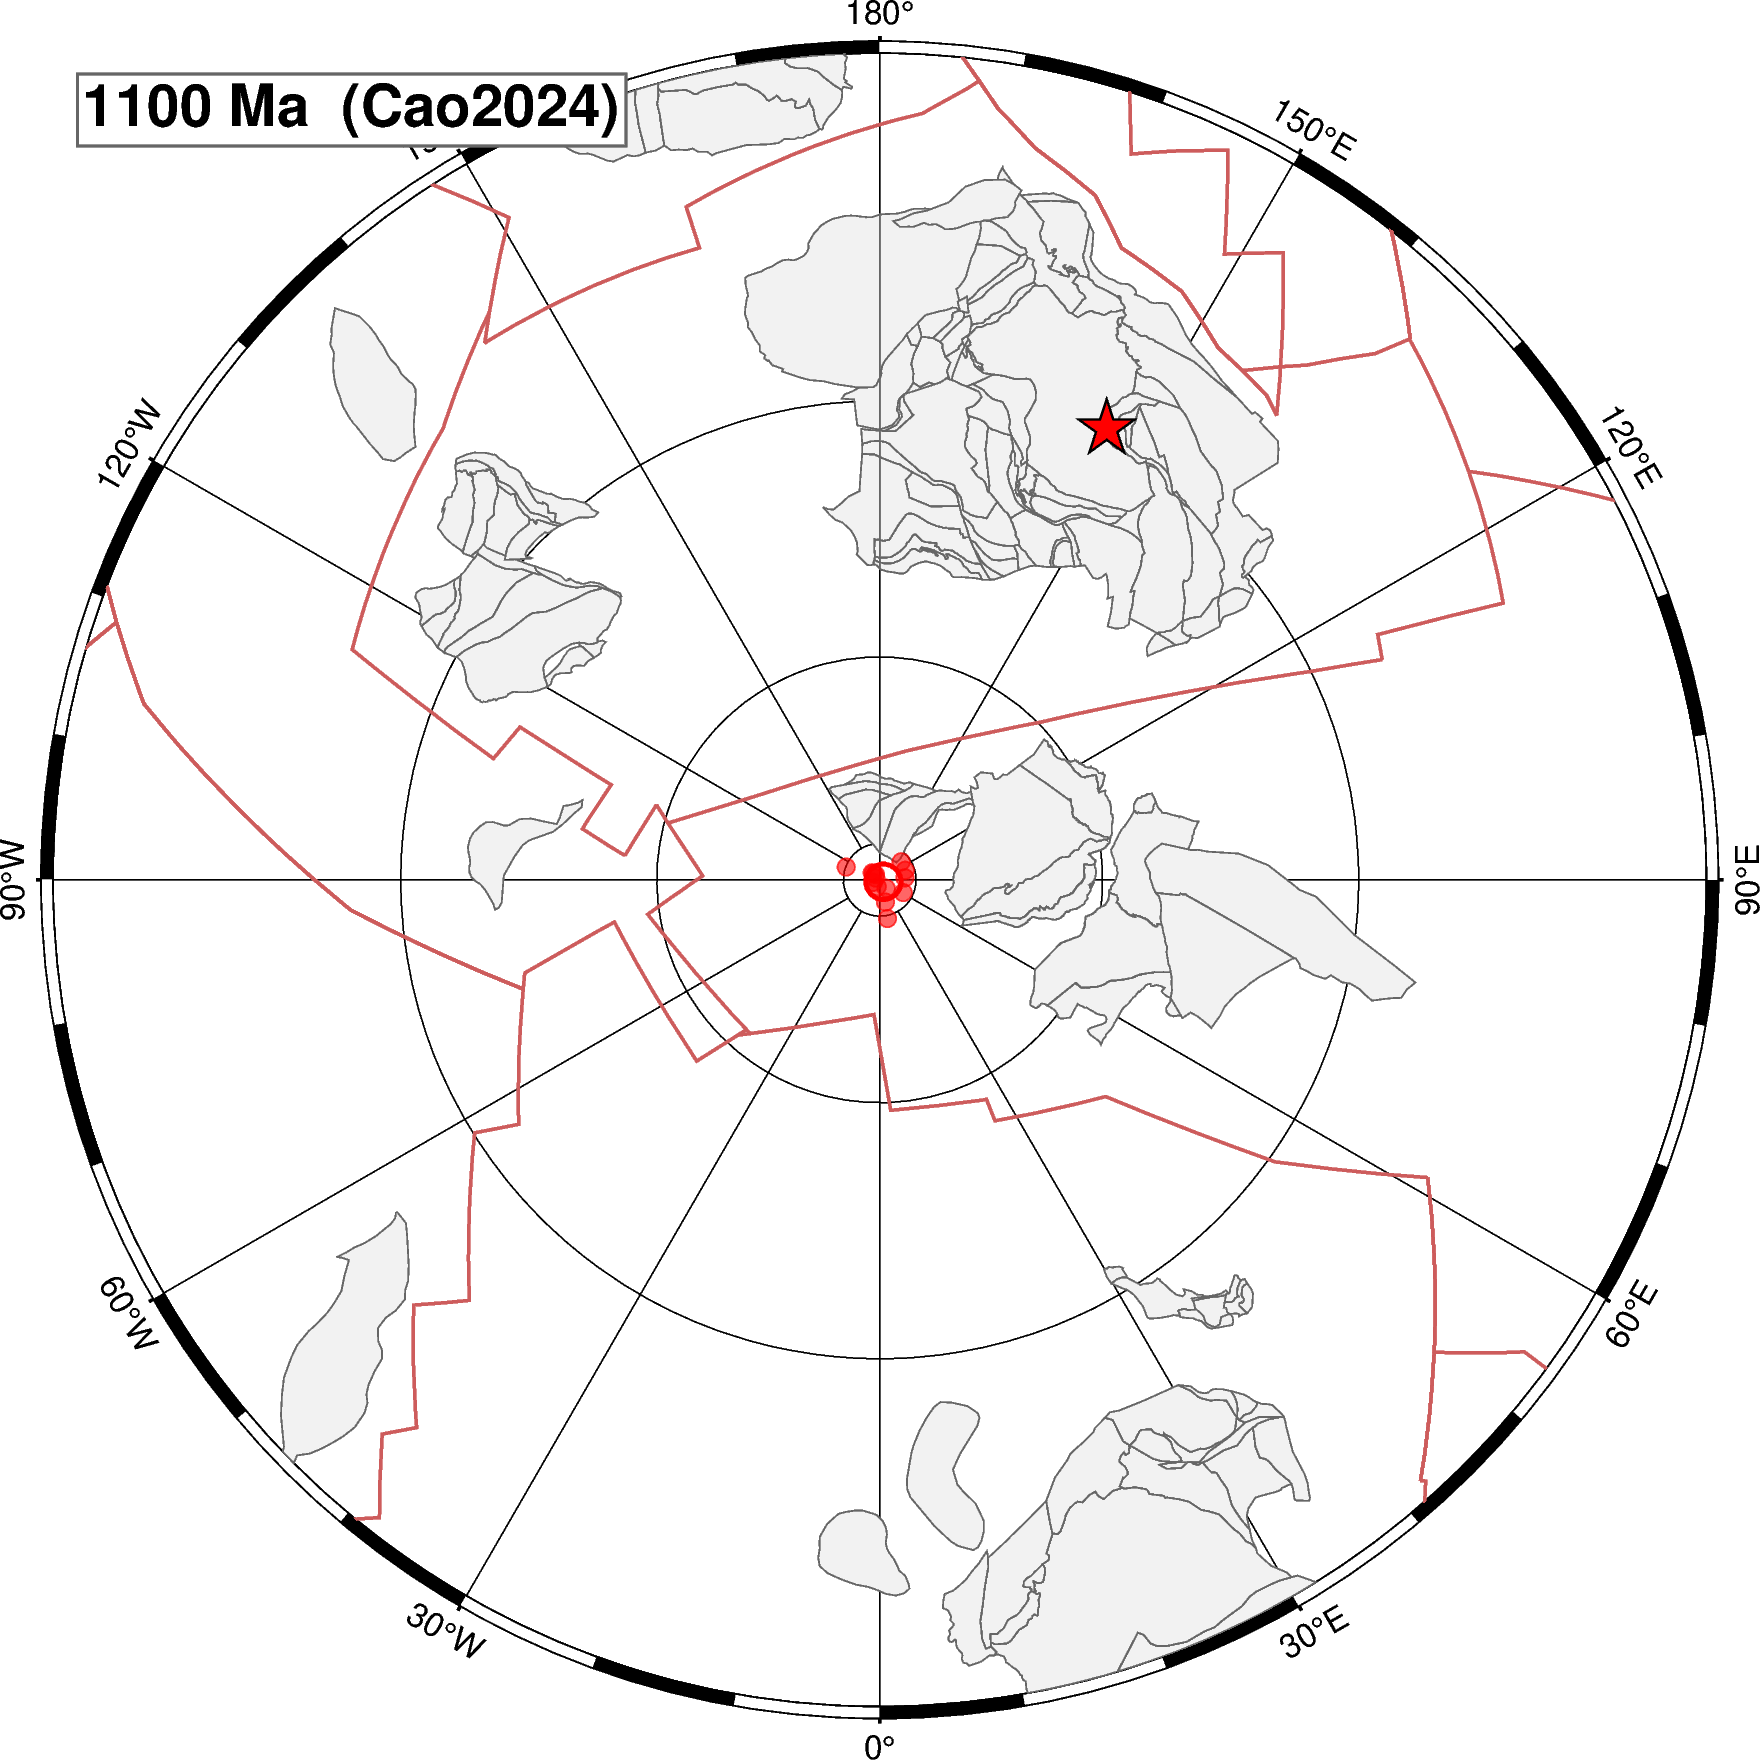

In [7]:
# Cell 6 — render the paleo-Earth panel
# PROJECTION: polar stereographic centred on the geographic north
# pole. The VGP cluster at the spin axis sits at the centre of the
# panel, with continents distributed around the periphery. We use the
# full visible hemisphere (horizon = 90° from the projection centre,
# i.e. all of 0°-90°N).
#
# Sites' plate IDs come from partitioning their PRESENT-DAY positions
# (so each VGP rotates with Laurentia regardless of where the VGP itself
# sits today).
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECONSTRUCTION_TIME),
)
engine = gplately.PygmtPlotEngine()

# Partition each site to assign its plate ID
site_partition = gplately.Points(recon,
                                 sites["lon"].values,
                                 sites["lat"].values)
site_partition.reconstruct(RECONSTRUCTION_TIME, return_array=True)
site_plate_ids = np.atleast_1d(site_partition.plate_id).astype(int)
print(f"  site plate IDs (unique): {sorted(set(site_plate_ids.tolist()))}")

# Apply each site's finite rotation to its own VGP, via pygplates
v_rlats = np.zeros(len(sites))
v_rlons = np.zeros(len(sites))
for i in range(len(sites)):
    pid = int(site_plate_ids[i])
    rot = rotation_model.get_rotation(
        float(RECONSTRUCTION_TIME), pid, anchor_plate_id=0)
    rotated = rot * pygplates.PointOnSphere(
        float(sites["vgp_lat"].iloc[i]),
        float(sites["vgp_lon"].iloc[i]))
    rl, rlo = rotated.to_lat_lon()
    v_rlats[i] = rl
    v_rlons[i] = rlo

# Mean pole rotates with the site centroid's plate ID
finite_rot_c = rotation_model.get_rotation(
    float(RECONSTRUCTION_TIME), SITE_PLATE_ID, anchor_plate_id=0)
pole_rotated = finite_rot_c * pygplates.PointOnSphere(
    float(pole_lat), float(pole_lon))
p_rlat, p_rlon = pole_rotated.to_lat_lon()
p_rlats = np.array([p_rlat])
p_rlons = np.array([p_rlon])

print(f"  reconstructed VGP cluster median: "
      f"lat = {np.median(v_rlats):+.1f}°, lon = {np.median(v_rlons):+.1f}°")
print(f"  reconstructed mean pole:          "
      f"lat = {float(p_rlats[0]):+.1f}°, lon = {float(p_rlons[0]):+.1f}°")
print( "  (expected near +90°N for synthetic-from-model data)")

fig = pygmt.Figure()
# Polar stereographic centred on the N geographic pole, horizon = 90°
# (full visible hemisphere, 0°-90°N). Stereographic is conformal
# (preserves angles/shapes locally), so the VGP cluster + a95 ring
# read naturally — this is the standard polar-paleomag projection.
fig.basemap(region=[-180, 180, 0, 90],
            projection="S0/90/90/14c",
            frame=["afg30"])

# Continuous topology backbone first, then continents on top
engine.plot_geo_data_frame(fig, gplot.get_continents(),
                           fill="gray95", pen="0.3p,gray40")
engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                           pen="0.7p,indianred")

# Reconstructed site centroid (star). It usually sits at low paleolatitude
# (south of the equator at 1.1 Ga in Cao 2024) so it may fall outside the
# 0-90°N polar projection footprint — plotted anyway; will only render if
# Laurentia at this age lies in the N hemisphere of the reconstruction.
fig.plot(x=rlons_centroid, y=rlats_centroid,
         style="a0.5c", fill="red", pen="0.4p,black")
# VGPs (transparent red dots) — should cluster at the centre of the panel
fig.plot(x=v_rlons, y=v_rlats, style="c0.15c",
         fill="red", pen="0.3p,red", transparency=40)
# Fisher mean pole as an α95 confidence ring at the centre of the panel
fig.plot(x=p_rlons, y=p_rlats, style=f"c{a95*0.20:.2f}c",
         fill=None, pen="1.0p,red")

# In-frame time-stamp
fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")

fig.show(width=900)
display(HTML('<div style="height:1cm"></div>'))


## What the figure shows

By construction the reconstructed Osler-like VGP cluster sits at the geographic pole of the chosen plate model at `RECONSTRUCTION_TIME`. The Fisher mean pole's α95 ring should encircle the spin axis, with the reconstructed site centroid (red star) at the paleolatitude the model predicts for Lake Superior at the rock age (in Cao 2024 at 1.1 Ga, somewhere south of the equator). The numerical residual printed above (Δ between predicted and observed paleolatitude) should be near zero.

This is a round-trip *consistency* test: it shows that a paleomagnetic pole observation — when treated as a passive marker on the same craton that hosted the rocks, and reconstructed through that craton's rotation — returns to the spin axis at the rock's magnetisation age, provided the pole is consistent with the rotation model. The exercise is the paleomagnetic analogue of "do the inverse and forward map agree".

## Extend this

- **Swap to real data and watch the cluster shift off the pole.** Replace the synthetic-from-model data path in Cell 2 with the bundled Halls 1974 / Swanson-Hysell et al. 2014 directions (or any other published Mesoproterozoic Laurentia pole). The cluster moves away from the spin axis by an amount that is the *model-data residual* — a measure of how well the rotation model fits this particular paleomag observation. For Cao 2024 vs the upper Osler pole at 1.1 Ga the offset is currently ~30°, reflecting genuine Mesoproterozoic paleogeography uncertainty.
- **Swap plate models.** Re-run with `MODEL_NAME = "Merdith2021"` (1 Ga coverage). The predicted Laurentia pole position at 1.1 Ga will be different; the synthetic data updates accordingly. The cluster again lands at the spin axis under that model, by construction.
- **Sweep the reconstruction time.** Loop `RECONSTRUCTION_TIME` from 1080 to 1120 Ma. The synthetic-data path moves smoothly because the model rotation moves smoothly. Useful as a sanity check that the rotation interpolation is well-behaved across the 5-Myr boundaries.
- **Increase site scatter.** Bump `SITE_SIGMA_DEG` to 5° or 8° and re-run. The reconstructed cluster spreads accordingly; the Fisher α95 ring grows; the mean stays on the spin axis. Useful to build intuition about how within-pole dispersion translates into uncertainty on the reconstructed cluster.
- **Connect to T24/T25.** T24 builds a paleomagnetic reference frame from the GPMDB (https://www.earth.northwestern.edu/~amir/gpmdb/); T25 compares alternative frames. Use T24's GPMDB-derived frame as `MODEL_NAME` here and check that the round-trip is still clean.

## References

- Halls, H.C. (1974). A paleomagnetic reversal in the Osler Volcanic Group, northern Lake Superior. *Canadian Journal of Earth Sciences* 11, 1200–1207.
- Swanson-Hysell, N.L., Vaughan, A.A., Mustain, M.R. & Asp, K.E. (2014). Confirmation of progressive plate motion during the Midcontinent Rift's early magmatic stage from the Osler Volcanic Group, Ontario, Canada. *Geochemistry, Geophysics, Geosystems* 15, 2039–2047. https://doi.org/10.1002/2013GC005180
- Cao, X., Collins, A.S., Pisarevsky, S., Flament, N., Li, S., Hasterok, D. & Müller, R.D. (2024). A deep-time Phanerozoic to Proterozoic plate motion model at 1° resolution. *Earth System Science Data* 16, 4007–4032. https://doi.org/10.5194/essd-16-4007-2024
- Mather, B.R. et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., et al. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20, 5556–5564.
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing published plate-reconstruction models. *Zenodo*. https://github.com/michaelchin/plate-model-manager
- Tauxe, L. (2010). *Essentials of Paleomagnetism.* University of California Press. (Inclination → paleolatitude derivation: §16.2.)
- Butler, R.F. (1992). *Paleomagnetism: Magnetic Domains to Geologic Terranes.* Blackwell Scientific. (Site-to-VGP transform: chapter 7.)
